# Module 6: Predictive distributions (Python)

- **License**: CC BY 4.0
- **Source authors**: Jean-Gabriel Young <jyoung22@uvm.edu>

We will simulate from prior and posterior predictive distributions, first for globe tosses and then for daily maximum temperatures.

<!-- CODEX-NEW: predictive-distribution adaptation requested by instructor -->
## Setup

In [ ]:
%pip install -q cmdstanpy==1.3.0

In [ ]:
from pathlib import Path
import shutil
import urllib.request

In [ ]:
import cmdstanpy
from cmdstanpy import CmdStanModel
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
CMDSTAN_VERSION = "2.39.0"
cmdstan_dir = Path(f"/content/cmdstan-{CMDSTAN_VERSION}")
archive_path = Path(f"/content/colab-cmdstan-{CMDSTAN_VERSION}.tgz")

In [ ]:
archive_url = (
    f"https://github.com/stan-dev/cmdstan/releases/download/v{CMDSTAN_VERSION}/"
    f"colab-cmdstan-{CMDSTAN_VERSION}.tgz"
)

In [ ]:
if not cmdstan_dir.exists():
    urllib.request.urlretrieve(archive_url, archive_path)
    shutil.unpack_archive(archive_path, "/content")

In [ ]:
cmdstanpy.set_cmdstan_path(str(cmdstan_dir))
print(f"CmdStanPy {cmdstanpy.__version__}")
print(f"CmdStan {cmdstanpy.cmdstan_version()}")

CmdStanPy 1.3.0
CmdStan (2, 39)


## 1. Globe tosses

Remember the model we're studying: We are taking uniform measurements of whether a point on a globe is land or water.
This information is stored in a vector $X$.
Our goal is to use these measurements to infer $\rho$, the fraction of the globe covered by land.
We code **land as 1** and **water as 0**.

In [ ]:
X = [1, 0, 0, 1, 0, 1, 0] # Land, Water, Water, Land, Water, Land, Water

### One model, two predictive distributions

We can simulate from the prior predictive distribution by

1. sampling parameters from the prior $p(\theta)$;
2. for each parameter sample, sampling a new data set from the likelihood $p(\widetilde X\mid\theta)$.

For posterior predictions, we instead sample the parameters from $p(\theta\mid X)$.

The `data` block includes a switch, `use_likelihood`:

- `0`: leaves the likelihood contribution to the density out of the model, and thus let's us sample from the prior distribution only;
- `1`: includes the likelihood contribution and thus generates samples from the posterior.

The `generated quantities` block simulates new tosses for every parameter draw.
It is the same in both runs.
`M` is the number of tosses in each simulated data set.

In [ ]:
stan_code = r"""
data {
  int<lower=1> N;
  array[N] int<lower=0, upper=1> X;
  int<lower=1> M;
  int<lower=0, upper=1> use_likelihood;
}
parameters {
  real<lower=0, upper=1> rho;
}
model {
  rho ~ beta(1.5, 1.5);
  if (use_likelihood == 1) {

    X ~ bernoulli(rho);
  }
}
generated quantities {
  array[M] int<lower=0, upper=1> X_rep;
  for (m in 1:M) {
    X_rep[m] = bernoulli_rng(rho);
  }
}
"""

Note that the "sampling" statement `~` is used to specify the model only.
To actually generate random numbers, we have to use `bernoulli_rng(rho)`.
You can find the syntax for this type of functions in [Stan's function reference](https://mc-stan.org/docs/functions-reference/).

Note that all `M` tosses in one simulated data set use the **same draw of `rho`**. The generated block can perform arbitrary computation on each individual samples.

In [ ]:
stan_file = Path("/content/globe_predictive.stan")
stan_file.write_text(stan_code);

In [ ]:
model_globe = CmdStanModel(stan_file=str(stan_file))

### Prior predictions

First we'll leave the likelihood out.
The observed values in `X` do not intervene in these draws.

In [ ]:
M = len(X)
prior_data = {"N": len(X), "X": X, "M": M, "use_likelihood": 0}
fit_prior = model_globe.sample(data=prior_data, chains=2, seed=6300)

chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

In [ ]:
X_prior = fit_prior.stan_variable("X_rep")
X_prior[:5]

array([[1., 1., 1., 1., 0., 1., 0.],
       [0., 1., 1., 0., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 0., 1., 1.],
       [0., 0., 1., 1., 0., 1., 0.]])

Each row is one simulated data set.
We have 2,000 rows because we requested two chains with 1,000 retained draws each.
The histogram below shows how many of the `M` tosses landed on land across the 2000 simulations of M = N tosses.

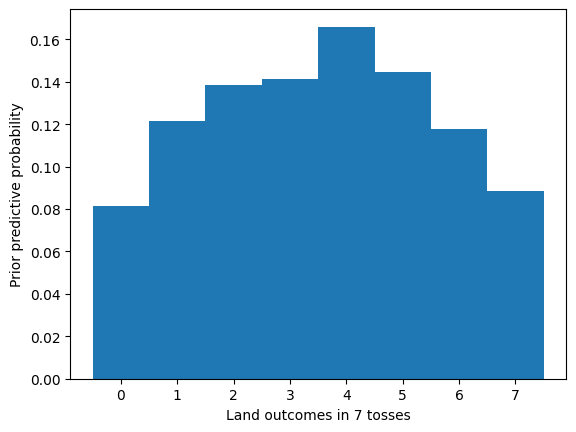

In [ ]:
bins = np.arange(M + 2) - 0.5
plt.hist(X_prior.sum(axis=1), bins=bins, density=True)
plt.xlabel(f"Land outcomes in {M} tosses")
plt.ylabel("Prior predictive probability")
plt.show()

**Try it:** Before fitting, predict what would change if the prior were `beta(10, 10)`.
Then edit the prior, recompile, and rerun the prior simulation.
Restore `beta(1.5, 1.5)` and rerun before continuing.

### Posterior predictions

Now let's include the likelihood.
The posterior predictive distribution is identical to the prior predictive distribution, but we now average over the posterior distribution of the parameters instead of the prior.

In [ ]:
posterior_data = {**prior_data, "use_likelihood": 1}
fit_posterior = model_globe.sample(data=posterior_data, chains=2, seed=6301)

chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

In [ ]:
X_posterior = fit_posterior.stan_variable("X_rep")
X_posterior[:5]

array([[1., 0., 0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 1., 0., 0.],
       [1., 0., 0., 1., 0., 1., 0.],
       [1., 0., 0., 1., 0., 0., 0.],
       [1., 0., 0., 1., 1., 0., 0.]])

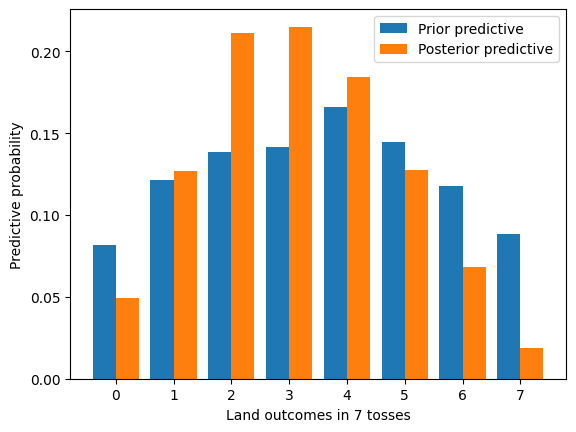

In [ ]:
plt.hist([X_prior.sum(axis=1), X_posterior.sum(axis=1)], bins=bins, density=True, label=["Prior predictive", "Posterior predictive"])
plt.xlabel(f"Land outcomes in {M} tosses")
plt.ylabel("Predictive probability")
plt.legend()
plt.show()

We can again ask probabilistic questions about the predicted data.
For example, what is the probability of at least five land outcomes in a new set of seven tosses?

We estimate this quantity by counting how often that event occurs in our simulations.

In [ ]:
np.mean(X_posterior.sum(axis=1) >= 5)

np.float64(0.214)

**Try it:** Change `M` to `20`, leaving `X` unchanged, and rerun from the prior sampling cell.

What changes about the predicted counts?

Does changing the number of future tosses give us more information about `rho`?

## 2. Normal data: September temperatures

The data we'll use comes from the Global Historical Climatology Network - Daily (GHCN-Daily) database, specifically daily maximum temperature readings from the Central Park weather station in New York City.
These are the September 2022 observations from Module 5, in degrees Celsius.

Questions one might want to understand include, for example, what is the typical maximum temperature in September, and how much does it vary?

In [ ]:
y = [
    28.3, 26.7, 26.7, 28.9, 30.6, 32.2, 27.8, 26.1, 25.0, 25.0,
    26.1, 26.1, 27.8, 26.1, 23.9, 21.7, 22.2, 22.8, 25.0, 26.1,
    28.3, 28.3, 20.6, 22.2, 23.9, 25.6, 23.9, 21.7, 20.0, 19.4,
]

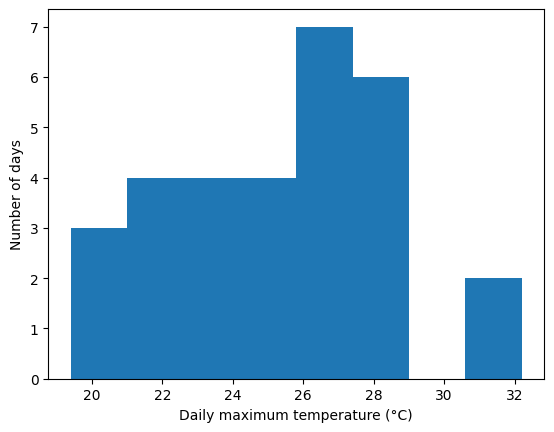

In [ ]:
plt.hist(y, bins=8)
plt.xlabel("Daily maximum temperature (°C)")
plt.ylabel("Number of days")
plt.show()

### The normal model

We use the normal model from Module 5, placing the prior directly on the standard deviation $\sigma$:

$$y_i\mid\mu,\sigma\overset{\mathrm{ind.}}{\sim}\mathrm{Normal}(\mu,\sigma^2),\qquad
\mu\sim\mathrm{Normal}^{+}(25,100),\qquad
\sigma\sim\mathrm{Normal}^{+}(0,100).$$

The two priors are independent.
The superscript $+$ means truncation below at zero; $100$ is the variance before we apply the truncation.
We truncate this prior because $\sigma$ is a positive quantity by definition.

Warning: **Stan's normal distribution takes a standard deviation as its second argument**, so the code uses `10` for the priors and `sigma` for the likelihood.

Also note that conditional independence is an assumption of this simple model. In reality, consecutive days probably have related temperatures. We'll learn how to model this type of data later.

In [ ]:
normal_code = r"""
data {
  int<lower=1> N;
  vector[N] y;
  int<lower=0, upper=1> use_likelihood;
}
parameters {
  real<lower=0> mu;
  real<lower=0> sigma;
}
model {
  mu ~ normal(25, 10);
  sigma ~ normal(0, 10);
  if (use_likelihood == 1) {
    y ~ normal(mu, sigma);
  }
}
generated quantities {
  vector[N] y_rep;
  for (n in 1:N) {
    y_rep[n] = normal_rng(mu, sigma);
  }
}
"""

In [ ]:
normal_file = Path("/content/normal_predictive.stan")
normal_file.write_text(normal_code);

In [ ]:
model_normal = CmdStanModel(stan_file=str(normal_file))

### Prior predictions

The procedure is unchanged from the globe toss example.
For each pair `(mu, sigma)` drawn from the prior, Stan simulates one data set of `N` temperatures.

In [ ]:
normal_prior_data = {"N": len(y), "y": y, "use_likelihood": 0}
fit_normal_prior = model_normal.sample(data=normal_prior_data, chains=2, seed=6302)

chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

In [ ]:
y_prior = fit_normal_prior.stan_variable("y_rep")
y_prior.shape

(2000, 30)

Each row contains one simulated data set of 30 days.

Pooling the rows shows the temperatures the model predicts before learning from the observations.

Are these predictions plausible for daily maximum temperatures in Central Park in September?

Probably not... but let's accept the prior provisionally. The data can speak for itself.

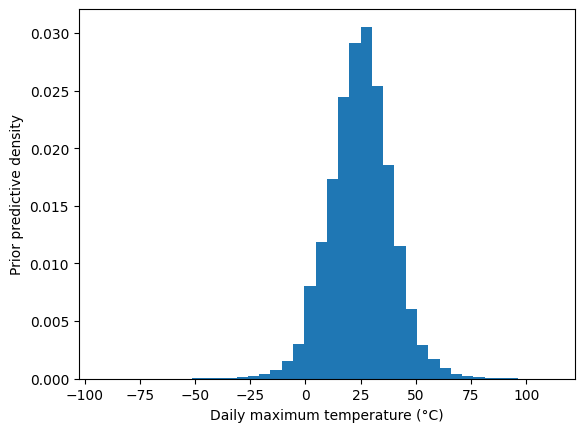

In [ ]:
plt.hist(y_prior.ravel(), bins=40, density=True)
plt.xlabel("Daily maximum temperature (°C)")
plt.ylabel("Prior predictive density")
plt.show()

### Posterior predictions

We turn the likelihood on and use the same `generated quantities` block.

Each simulated data set now uses a pair `(mu, sigma)` drawn from the joint posterior.

In [ ]:
normal_posterior_data = {**normal_prior_data, "use_likelihood": 1}
fit_normal_posterior = model_normal.sample(data=normal_posterior_data, chains=2, seed=6303)

chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

Exception: normal_lpdf: Location parameter is inf, but must be finite! (in 'normal_predictive.stan', line 15, column 4 to column 26)
Exception: normal_lpdf: Location parameter is inf, but must be finite! (in 'normal_predictive.stan', line 15, column 4 to column 26)
	Exception: normal_lpdf: Location parameter is inf, but must be finite! (in 'normal_predictive.stan', line 15, column 4 to column 26)
	Exception: normal_lpdf: Location parameter is inf, but must be finite! (in 'normal_predictive.stan', line 15, column 4 to column 26)
	Exception: normal_lpdf: Location parameter is inf, but must be finite! (in 'normal_predictive.stan', line 15, column 4 to column 26)
	Exception: normal_lpdf: Location parameter is inf, but must be finite! (in 'normal_predictive.stan', line 15, column 4 to column 26)
Consider re-running with show_console=True if the above output is unclear!


In [ ]:
y_posterior = fit_normal_posterior.stan_variable("y_rep")
y_posterior.shape

(2000, 30)

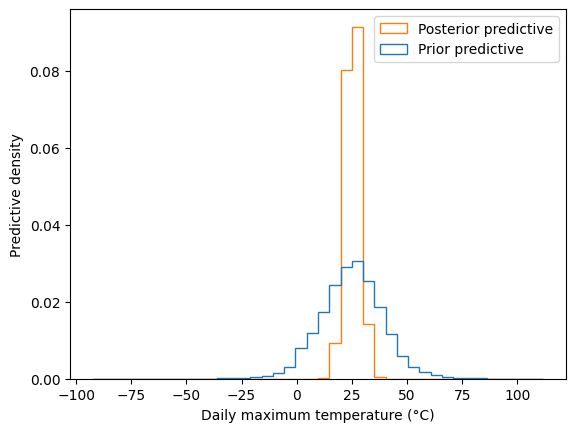

In [ ]:
plt.hist([y_prior.ravel(), y_posterior.ravel()], bins=40, density=True, histtype="step", label=["Prior predictive", "Posterior predictive"])
plt.xlabel("Daily maximum temperature (°C)")
plt.ylabel("Predictive density")
plt.legend()
plt.show()

We can also look at individual simulated data sets.

The first three rows below are three possible sets of 30 daily maximum temperatures under the fitted model.

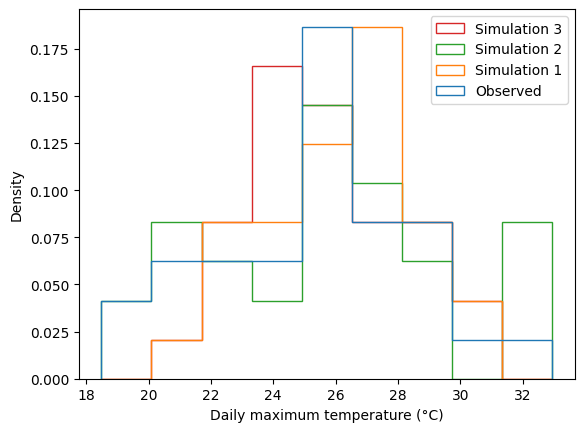

In [ ]:
temperature_bins = np.linspace(min(min(y), y_posterior[:3].min()), max(max(y), y_posterior[:3].max()), 10)
plt.hist([y, *y_posterior[:3]], bins=temperature_bins, density=True, histtype="step", label=["Observed", "Simulation 1", "Simulation 2", "Simulation 3"])
plt.xlabel("Daily maximum temperature (°C)")
plt.ylabel("Density")
plt.legend()
plt.show()

**Try it:** Compare the variability within one simulated data set with the variability between the simulated data sets.
Why do future temperatures still vary when we have learned about the parameters?

Change the prior on `mu` to `normal(25, 2)`, then recompile and rerun the normal example.
Does the change affect the prior and posterior predictions to the same extent?